# 数值分析

In [ ]:
# Required packages for this notebook: torch, matplotlib, numpy, torchdiffeq
# If needed, install them with: pip install torch matplotlib numpy torchdiffeq

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp


plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

## 常微分方程的数值模拟

我们考虑受控后系统：
\begin{align*}
    \dot{x}(t)=F\bigl(t,x(t)\bigr)
    &&  x(t_0)=x_0
\end{align*}
该系统可以近似为离散时间系统：
\begin{align*}
    \hat x(t_{i+1}) = \hat x(t_i)
    + F\bigl(t,x(t_i)\bigr) \Delta t
    && x(t_0)=x_0
    && t_{i+1} = t_0 + (i+1) \Delta
\end{align*}
从而，我们可以利用计算机通过对离散时间系统的迭代来近似求解原系统的解。

我们以没有外力控制的弹簧系统为例，
\begin{align*}
        \begin{cases}
            \dot{p}(t)=v(t),\\[2pt]
            \dot{v}(t)=-\dfrac{k}{m}p(t)-\dfrac{c}{m}v(t)
        \end{cases}
        \Longleftrightarrow
        \begin{cases}
            \dot{x}_1(t)=x_2(t),\\[2pt]
            \dot{x}_2(t)=-\dfrac{k}{m}x_1(t)-\dfrac{c}{m}x_2(t)
        \end{cases}
\end{align*}

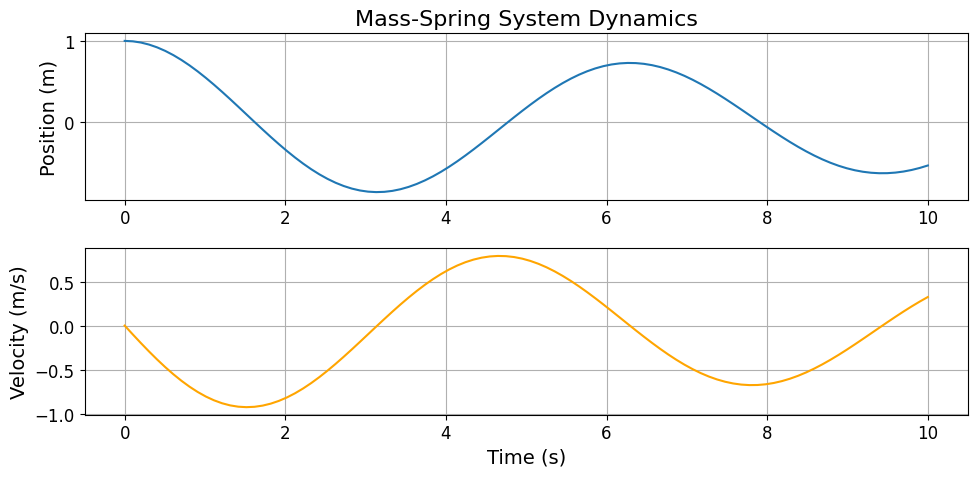

In [2]:
# Define the parameters for the mass-spring system
k = 1.0  # spring constant
m = 1.0  # mass
c = 0.1  # damping coefficient


def F(t, x, k=k, m=m, c=c):
    # Define the system of ODEs for the mass-spring system
    # x[0] = position, x[1] = velocity
    dxdt = [x[1], -k / m * x[0] - c / m * x[1]]
    return dxdt


# Define the time span and initial conditions
t_span = (0, 10)  # time span for the simulation
t_eval = np.linspace(t_span[0], t_span[1], 100)  # time points to evaluate the solution
x0 = [1.0, 0.0]  # initial position and velocity

# Solve the ODE using solve_ivp
solution = solve_ivp(F, t_span, x0, t_eval=t_eval)


# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(solution.t, solution.y[0], label='Position (m)')
plt.title('Mass-Spring System Dynamics')
plt.ylabel('Position (m)')
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(solution.t, solution.y[1], label='Velocity (m/s)', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.grid()
plt.tight_layout()  

接下来，我们来看一下不同数值方法的精度。对于该系统，其显示解（解析解）为：
\begin{align*}
    x(t) = e^{A(t-t_0)} x_0, \qquad
    A = \begin{bmatrix} 0 & 1 \\[2pt] -\frac{k}{m} & -\frac{c}{m} \end{bmatrix}
\end{align*}
我们利用$L_2$距离来刻画误差,即$\int_{t_0}^t \|x(t)-\hat x(t)\|^2 dt$。

In [3]:
# explicit solution
A = np.array([[0, 1], [-k / m, -c / m]])
explicit_solution = np.zeros((2, len(solution.t)))

for i in range(len(solution.t)):
    explicit_solution[:, i] = scipy.linalg.expm(A * solution.t[i]) @ x0


# Euler method implementation
solution_Euler = np.zeros((2, len(solution.t)))
solution_Euler[:, 0] = x0
for i in range(1, len(solution.t)):
    dt = solution.t[i] - solution.t[i - 1]
    solution_Euler[:, i] = solution_Euler[:, i - 1] + dt * np.array(F(solution.t[i - 1], solution_Euler[:, i - 1]))


# Compute the error between the explicit solution and the RK4 solution
error_rk4 = np.linalg.norm(explicit_solution - solution.y, axis=0)**2 
error_euler = np.linalg.norm(explicit_solution - solution_Euler, axis=0)**2 
Delta = solution.t[1] - solution.t[0]
print("Max error (Euler):", np.sum(error_euler) * Delta)
print("Max error (RK4):  ", np.sum(error_rk4) * Delta)

Max error (Euler): 0.6058309632303349
Max error (RK4):   9.960022597998015e-06


### 向量场(Vector Field)与相图(Phase Portrait)

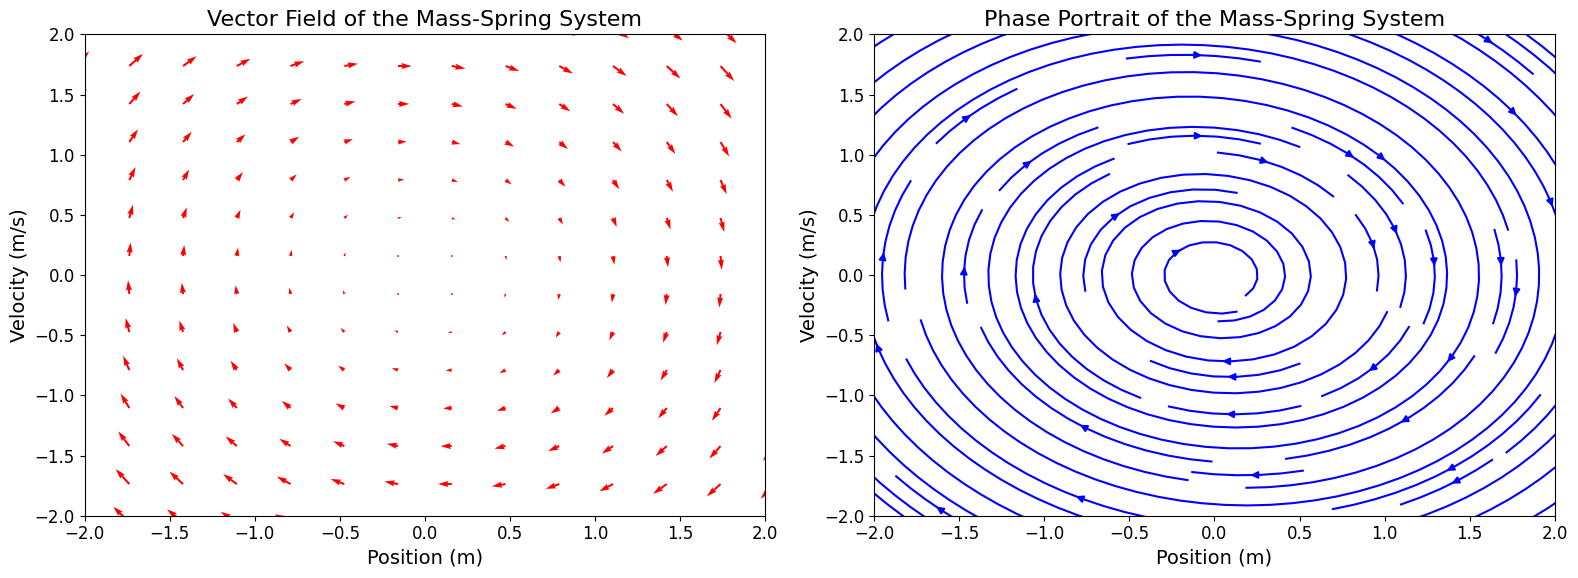

In [4]:
c = 0.1  # damping coefficient


# 左图：向量场
x1_space = np.linspace(-3, 3, 20)
x2_space = np.linspace(-3, 3, 20)

X1, X2 = np.meshgrid(x1_space, x2_space) # create a grid of points

VF = F(0, np.array([X1, X2]), c=c) # the vector field

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ax1.quiver(X1, X2, VF[0], VF[1], color='red')
ax1.set_title('Vector Field of the Mass-Spring System')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Velocity (m/s)')
ax1.set_xlim([-2, 2])
ax1.set_ylim([-2, 2])

# 右图：相图
x1_space = np.linspace(-3, 3, 100)
x2_space = np.linspace(-3, 3, 100)

X1, X2 = np.meshgrid(x1_space, x2_space) # create a grid of points

VF = F(0, np.array([X1, X2]), c=c) # the vector field

ax2.streamplot(X1, X2, VF[0], VF[1], color='blue', density=1.5)
ax2.set_title('Phase Portrait of the Mass-Spring System')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_xlim([-2, 2])
ax2.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

## 参数估计

### 全状态频繁测量

我们依旧考虑上述弹簧系统。假设我们可以频繁地测量系统的状态 $x(t)$ 与输入 $u(t)$，即得到一组离散时间的测量数据 $\{(x(t_i),u(t_i))\}_{i=0}^{N}$，其中 $t_i = t_0 + i \Delta t$，且$\Delta t$较小。

并通过求解下述最优化问题，来实现参数估计：
\begin{align*}
    \hat{\theta} = \arg\min_{\theta} \sum_{i=0}^{N-1} \left\| \frac{x(t_{i+1})-x(t_{i})}{\Delta t} - F\bigl(t_i,x(t_i;\theta\bigr) \right\|^2
\end{align*}   

这里我们考虑$m=1$，但参数$k$与$c$未知。


In [20]:
# generate data for parameter estimation

t_span = (0, 10)  # time span for the simulation
t_eval = np.linspace(t_span[0], t_span[1], 501)

explicit_solution = np.zeros((2, len(t_eval)))
for i in range(len(t_eval)):
    explicit_solution[:, i] = scipy.linalg.expm(A * t_eval[i]) @ x0


# identification algorithm

import torch

def F_torch(t, x, theta):
    return torch.stack((
        x[1],
        -theta[0]  * x[0] - theta[2] * x[1],
    ))

def loss_function(theta, solution_explicit, t_eval):
    solution_explicit = torch.as_tensor(solution_explicit, dtype=torch.float32)
    t_eval = torch.as_tensor(t_eval, dtype=torch.float32)
    loss = torch.zeros((), dtype=torch.float32)
    for i in range(solution_explicit.shape[1] - 1):
        dxdt_estimated = F_torch(t_eval[i], solution_explicit[:, i], theta)
        difference = (solution_explicit[:, i + 1] - solution_explicit[:, i]) / (t_eval[i + 1] - t_eval[i])
        loss = loss + torch.sum((dxdt_estimated - difference) ** 2)
    return loss

theta = torch.tensor([5.0, 1.0, 2.0], requires_grad=True)  # initial guess for k, m, c

optimizer = torch.optim.Adam([theta], lr=0.01)

for epoch in range(2000):
    loss = loss_function(theta, explicit_solution, t_eval)
    loss.backward()  # compute gradients

    optimizer.step()  # update parameters
    optimizer.zero_grad()  # reset gradients

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}, Parameters: {theta.detach().numpy()}')

print("Actual parameters: k =", k, ", m =", m, ", c =", c)

Epoch 0, Loss: 2911.1923828125, Parameters: [4.99 1.   1.99]
Epoch 100, Loss: 1571.853515625, Parameters: [4.0340786 1.        1.1182818]
Epoch 200, Loss: 808.1558227539062, Parameters: [3.2094905  1.         0.60963905]
Epoch 300, Loss: 386.2508850097656, Parameters: [2.5328147 1.        0.3750192]
Epoch 400, Loss: 167.01583862304688, Parameters: [2.0077965  1.         0.26638728]
Epoch 500, Loss: 64.4104232788086, Parameters: [1.6251193  1.         0.20434403]
Epoch 600, Loss: 21.97643280029297, Parameters: [1.3643914  1.         0.16468233]
Epoch 700, Loss: 6.60242223739624, Parameters: [1.1989456  1.         0.13983257]
Epoch 800, Loss: 1.745985984802246, Parameters: [1.101367   1.         0.12521699]
Epoch 900, Loss: 0.4124791920185089, Parameters: [1.0479273  1.         0.11721818]
Epoch 1000, Loss: 0.09505482017993927, Parameters: [1.0207714  1.         0.11315427]
Epoch 1100, Loss: 0.02976948954164982, Parameters: [1.0079812  1.         0.11124028]
Epoch 1200, Loss: 0.018218783

### 非理想数据情况下的参数估计方法

我们考虑弹簧系统，只能在比较稀疏的时间点上测量到弹簧的位置。

我们使用的优化目标为：
\begin{align*}
    \hat{\theta} = \arg\min_{\theta} \sum_{i=0}^{N} \left\| y(t_i) - h(\Psi(t_i,x_0; \theta)) \right\|^2
\end{align*}

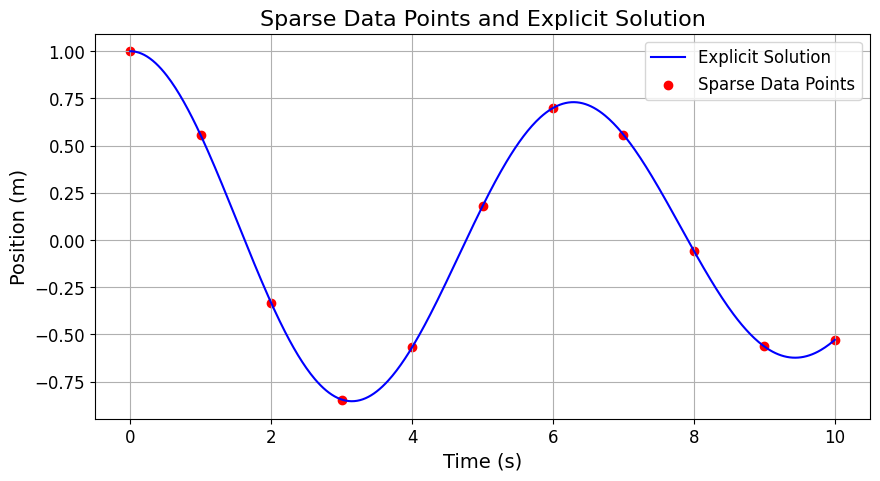

In [27]:
# 产生数据

t_eval_sparse = t_eval[::50]  # sparse time points for parameter estimation
y_sparse = explicit_solution[0, ::50]  # corresponding sparse solution

# plot the sparse data points and the explicit solution
plt.figure(figsize=(10, 5))
plt.plot(t_eval, explicit_solution[0, :], label='Explicit Solution', color='blue')
plt.scatter(t_eval_sparse, y_sparse, color='red', label='Sparse Data Points')
plt.title('Sparse Data Points and Explicit Solution')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid()

In [38]:
# do gradient descent to estimate parameters from sparse data

from torchdiffeq import odeint

def loss_function_sparse(theta, t_eval_sparse, y_sparse):
    # simulate the system using the current parameters theta
    x0 = torch.tensor([1.0, 0.0], dtype=torch.float32)  # initial conditions
    solution_sparse = torch.zeros((2, len(t_eval_sparse)), dtype=torch.float32)
    solution_sparse[:, 0] = x0
    solution_sparse = odeint(lambda t, x: F_torch(t, x, theta), solution_sparse[:, 0], torch.as_tensor(t_eval_sparse, dtype=torch.float32))

    # compute the loss as the mean squared error between the simulated and sparse data
    y_simulated = solution_sparse[:, 0]  # only take the position component
    loss = torch.mean((y_simulated - torch.as_tensor(y_sparse, dtype=torch.float32)) ** 2)
    return loss


# do gradient descent to estimate parameters from sparse data

theta_sparse = torch.tensor([5.0, 1.0, 2.0], requires_grad=True)  # initial guess for k, m, c

optimizer_sparse = torch.optim.Adam([theta_sparse], lr=0.01)

for epoch in range(1000):
    loss_sparse = loss_function_sparse(theta_sparse, t_eval_sparse, y_sparse)
    loss_sparse.backward()  # compute gradients

    optimizer_sparse.step()  # update parameters
    optimizer_sparse.zero_grad()  # reset gradients

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss_sparse.item()}, Parameters: {theta_sparse.detach().numpy()}')


Epoch 0, Loss: 0.2619220018386841, Parameters: [4.99 1.   2.01]
Epoch 100, Loss: 0.2376421093940735, Parameters: [4.0872207 1.        2.7245123]
Epoch 200, Loss: 0.23406830430030823, Parameters: [3.5549366 1.        2.6382968]
Epoch 300, Loss: 0.22773799300193787, Parameters: [2.9428778 1.        2.141838 ]
Epoch 400, Loss: 0.16516965627670288, Parameters: [1.4617202 1.        0.8004181]
Epoch 500, Loss: 1.0338973197576706e-06, Parameters: [0.9994516  1.         0.09907956]
Epoch 600, Loss: 2.1301656619177045e-11, Parameters: [1.0000021  1.         0.09999999]
Epoch 700, Loss: 7.579921662125705e-14, Parameters: [0.99999994 1.         0.09999991]
Epoch 800, Loss: 1.4452202184555424e-13, Parameters: [1.         1.         0.09999996]
Epoch 900, Loss: 2.750741529087414e-13, Parameters: [0.99999994 1.         0.09999994]
